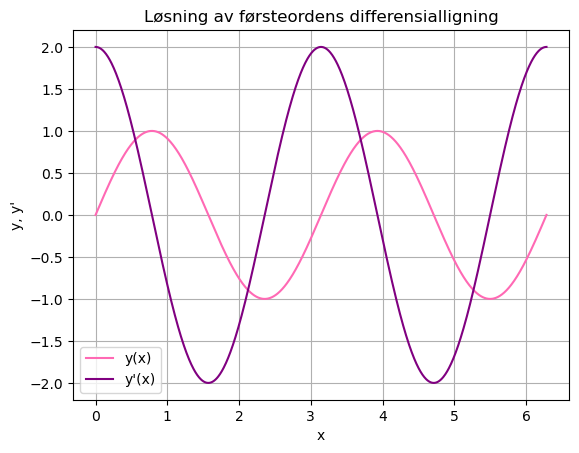

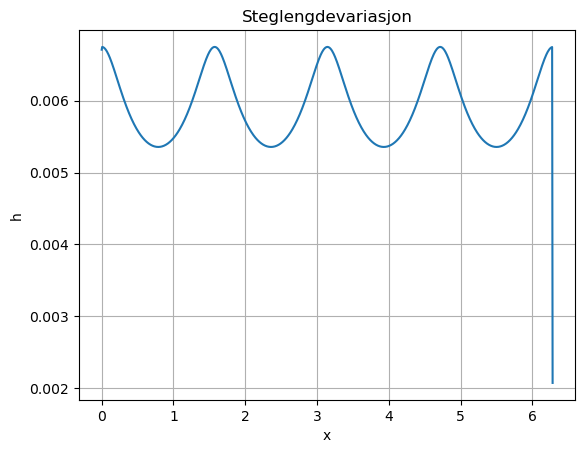

In [18]:
import numpy as np
import matplotlib.pyplot as plt


def f(x,y):
    return np.array([y[1], -4*np.sin(2*x)])

def solve_rk(f, x_init, x_end, y_init, h0, tol, alpha):
    n, m = 0, 0
    x_list = [x_init]
    y_list = [y_init]
    h_list = []

    x = x_init
    y = np.array(y_init)
    h = h0

    k1 = f(x, y)

    while x < x_end:
        n += 1
        
        if x + h > x_end:
            h = x_end - x

        k2 = f(x + h/2, y + h*k1/2)
        k3 = f(x + 3*h/4, y + 3*h*k2/4)

        y_next = y + h*(2*k1 + 3*k2 + 4*k3)/9
        k4 = f(x + h, y_next)
        
        z_next = y + h*(7*k1 + 6*k2 + 8*k3 + 3*k4)/24
        est = np.linalg.norm(y_next - z_next)

        if est < tol:
            m += 1
            x += h
            y = z_next ## y eller z?

            x_list.append(x)
            y_list.append(y)
            h_list.append(h)

            k1 = k4

        if est == 0:
            h = 2*h
        else:
            h = alpha*h*(tol/est)**(1/3)

    return np.array(x_list), np.array(y_list), np.array(h_list), n, m

x_init = 0.0
x_end = 2*np.pi
h0 = 0.1
tol = 10**(-7)
alpha = 0.8
y_init = np.array([0, 2])
y = y_init.copy()

x_vals, y_vals, h_vals, n, m = solve_rk(f, x_init, x_end, y_init, h0, tol, alpha)

y1 = y_vals[:, 0]
y2 = y_vals[:, 1]

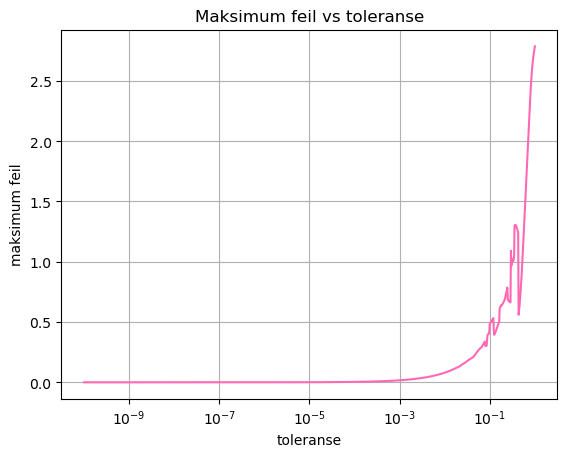

In [19]:
import numpy as np
import matplotlib.pyplot as plt

num = 1000
tols = np.logspace(-10, 0, num)
x_init = 0
x_end = 2 * np.pi
y_init = [0, 2]  
h0 = 1e-2
alpha = 0.8
tot_error = np.zeros(num)

for i, tol in enumerate(tols):
    x_vals, y_vals, h_vals, n, m = solve_rk(f, x_init, x_end, y_init, h0, tol, alpha)
    
    y1_vals = y_vals[:,0]
    tot_error[i] = np.max(np.abs(np.sin(2*x_vals) - y1_vals))

plt.plot(tols, tot_error, color = "hotpink")
plt.xlabel("toleranse")
plt.xscale("log")
plt.ylabel("maksimum feil")
plt.title("Maksimum feil vs toleranse")
plt.grid()
plt.show()


Fra plottet kan det observeres at den maksimale feilen øker med toleransen. Fra $10^{-10}$ frem til omtrent $10^{-4}$ viser plottet en lav feil som ser ut til å holde seg konstant. Dette vil si at metoden er svært nøyatig i dette ibetrvallet, og at det ikke vil være et stort behov for å redusere toleransen. 
Fra $10^{-4}$ til $10^{-2}$ øker feilen jevnt med en glatt kurve. I dette området styres feilen som forventet av toleransen, og metoden er stabil. For større toleranser observeres et avvik i plottet. Dette er ikke uventet ettersom en større toleranse vil tillate større feil per steg, og små endringer i toleranse kan dermed gi store utslag. Dette kan resultere i svinginger eller støy i plottet, og i dette området vil derfor ikke metoden fungere svært godt.


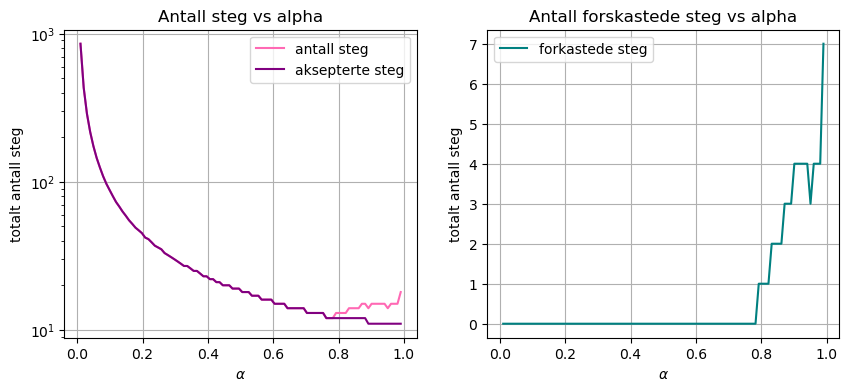

In [41]:
import numpy as np
import matplotlib.pyplot as plt

alpha_vals = np.linspace(0.01, 0.99, 100)
x_init = 0
x_end = 2 * np.pi
y_init = [0, 2]  
h0 = 1e-2
tol = 0.1
n_steps = []
a_steps = []
reject_steps = []


for alpha in alpha_vals:
    x_vals, y_vals, h_vals, num_steps, accepted_steps = solve_rk(f, x_init, x_end, y_init, h0, tol, alpha)
    n_steps.append(num_steps)
    a_steps.append(accepted_steps)
    reject_steps.append(num_steps - accepted_steps)


reject = len(n_steps) - len(a_steps)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(alpha_vals, n_steps, color = "hotpink", label = "antall steg")
plt.plot(alpha_vals, a_steps, color = "purple", label = "aksepterte steg")
plt.xlabel(r"$\alpha$")
plt.yscale("log")
plt.ylabel("totalt antall steg")
plt.title("Antall steg vs alpha")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(alpha_vals, reject_steps, label="forkastede steg", color = "teal")
plt.xlabel(r"$\alpha$")
plt.ylabel("totalt antall steg")
plt.title("Antall forkastede steg vs alpha")
plt.legend()
plt.grid()
plt.show()

Fra plottet observeres det at en økende alpha resulterer i at antall steg minker frem til $\alpha$ omtrent lik $0.8$. Dette har en sammenheng med formelen som brukes for å justere steglengden, $h_{new} = \alpha ·h·(\frac{tol}{est})^{1/3}$. Når $\alpha$ øker vil steglengden $h$ også gjøre det, og det vil dermed kreves et mindre antall steg for å nå $x_{end}$. Fra $\alpha = 0$ til  

Når $\alpha \approx 0.8$, øker antall steg for det totalte antallet steg tatt, mens de akspeterte stegene synker og flater ut. Ettersom en økende $\alpha$ gir en økning for $h$, kan dette resultere i at $est > tol$. Dermed vil flere steg måtte forkastes, og antall steg må dermed øke. Den mest optimale verdien for $\alpha$ vil altså være en $\alpha$ som er så høy som mulig uten at antall forkastede steg dominerer.